# Normality Test

In [ ]:
!pip install seaborn

### This code for run in Google Colab

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


# --- 1. Load Historical Data  ---
df = pd.read_csv("https://raw.githubusercontent.com/tranmaithang/tuhocquantfinance/master/assets/files/market_data/AAPL.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head(3)

,open,high,low,close,volume,vwap,timestamp,transactions,otc
0,182.16,184.26,180.934,183.63,65603041.0,182.8825,2024-01-16 05:00:00,767284,NaN
1,181.27,182.93,180.300,182.68,47317433.0,181.9201,2024-01-17 05:00:00,594632,NaN
2,186.09,189.14,185.830,188.63,78005754.0,187.9375,2024-01-18 05:00:00,787235,NaN


### This code for run in Local

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# --- 1. Load Historical Data  ---
df = pd.read_csv("market_data/AAPL.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head(3)

,open,high,low,close,volume,vwap,timestamp,transactions,otc
0,182.16,184.26,180.934,183.63,65603041.0,182.8825,2024-01-16 05:00:00,767284,NaN
1,181.27,182.93,180.300,182.68,47317433.0,181.9201,2024-01-17 05:00:00,594632,NaN
2,186.09,189.14,185.830,188.63,78005754.0,187.9375,2024-01-18 05:00:00,787235,NaN


In [3]:
# --- 2. Calculate Return ---
# Create a new DataFrame with only 'timestamp' and 'close'
df_prices = df[['timestamp', 'close']].copy()

# GBM Model (log-return): ln(P_t / P_{t-1})
log_returns = np.log(df_prices['close'] / df_prices['close'].shift(1)).dropna()
df_prices['log_returns'] = log_returns
df_prices.head(3)

,timestamp,close,log_returns
0,2024-01-16 05:00:00,183.63,NaN
1,2024-01-17 05:00:00,182.68,-0.005187
2,2024-01-18 05:00:00,188.63,0.032051


In [4]:
# --- 3. Calculate Statistics ---
s = stats.skew(log_returns)
k = stats.kurtosis(log_returns)
jb_stat, p_val = stats.jarque_bera(log_returns)
    
print(f"--- AAPL (Lognormal Fit) ---")
print(f"Skewness:            {s:.4f}")
print(f"Kurtosis:            {k:.4f}")
print(f"Jarque-Bera P-value: {p_val:.4e}")

--- AAPL (Lognormal Fit) ---
Skewness:            0.6364
Kurtosis:            11.7107
Jarque-Bera P-value: 0.0000e+00


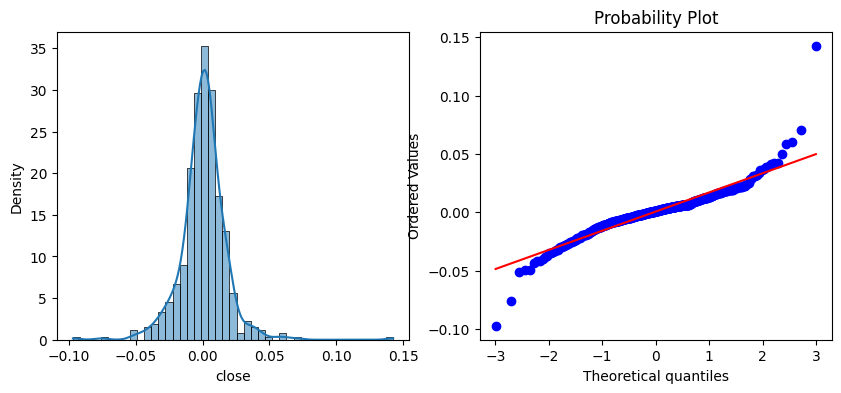

In [5]:
# --- 4. Plot Histograms, Q-Q Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(log_returns, kde=True, ax=axes[0], stat="density"); # Histogram
stats.probplot(log_returns, dist="norm", plot=axes[1]); # Q-Q Plot

# Calibrattion

In [6]:
# --- 5. Calibrattion ---
# --- Financial Approach ---
mean_annual = log_returns.mean() * 252
std_annual = log_returns.std() * np.sqrt(252)
    
# ---  MLE Approach ---
mu, sigma = stats.norm.fit(log_returns)
mu_annual = mu * 252
sigma_annual = sigma * np.sqrt(252)
    
results = pd.DataFrame({'Metric': ['Annual Drift (mu)', 'Annual Volatility (sigma)'],
    'Financial': [mean_annual, std_annual],
    'MLE': [mu_annual, sigma_annual]})
    
print(f"--- AAPL (Lognormal Fit) ---")
print(results.to_string(index=False))

--- AAPL (Lognormal Fit) ---
                   Metric  Financial      MLE
        Annual Drift (mu)   0.174843 0.174843
Annual Volatility (sigma)   0.276458 0.276182


# Forecasting

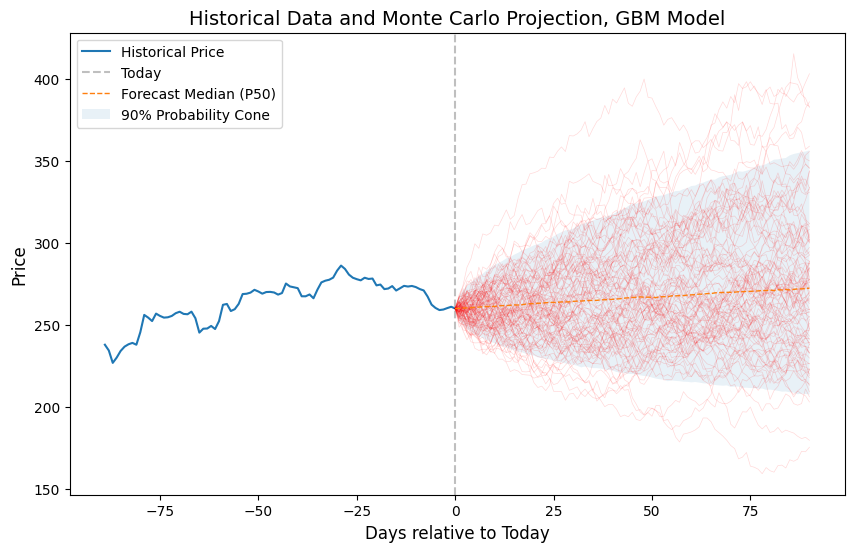

In [7]:
# --- 6 Simulation Parameters ---
S_initial = df_prices['close'].iloc[-1]
dt = 1 / 252            # Time step (1 day)
n_steps = 90            # 90 trading days
n_simulations = 10000   # 10000 scenarios

# --- 7. Projection Random Paths ---
np.random.seed(42)
dW_t = np.random.normal(loc=0, scale=np.sqrt(dt), size=(n_steps, n_simulations))
daily_growth = np.exp((mu_annual - 0.5 * sigma_annual**2) * dt + sigma_annual * dW_t)
simulated_paths = S_initial * np.cumprod(daily_growth, axis=0)
simulated_paths = np.vstack([np.full(n_simulations, S_initial), simulated_paths])

# --- 8. Visualization ---
plt.figure(figsize=(10, 6))

# Plot historical data
history_window = 90
historical_segment = df_prices['close'].iloc[-history_window:]
history_index = np.arange(-(history_window - 1), 1)
plt.plot(history_index, historical_segment, label='Historical Price')

# Plot simulation paths
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5, label='Today')
future_index = np.arange(0, n_steps + 1)
for i in range(100):
    plt.plot(future_index, simulated_paths[:, i], color='red', lw=0.5, alpha=0.15)

# Plot confidence intervals
median_path = np.percentile(simulated_paths, 50, axis=1)
p5 = np.percentile(simulated_paths, 5, axis=1)
p95 = np.percentile(simulated_paths, 95, axis=1)
plt.plot(future_index, median_path, lw=1, linestyle='--', label='Forecast Median (P50)')
plt.fill_between(future_index, p5, p95, alpha=0.1, label='90% Probability Cone')

plt.title(f"Historical Data and Monte Carlo Projection, GBM Model", fontsize=14)
plt.xlabel("Days relative to Today", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.show()

# Risk Management

In [8]:
S_initial= df['close'].iloc[-1]
n_steps = 10
n_simulations = 100000
mu_annual = mu * 252
sigma_annual = sigma * np.sqrt(252)
dt = 1/252

np.random.seed(42)
dW_t = np.random.normal(loc=0, scale=np.sqrt(dt), size=(n_steps, n_simulations))
daily_growth = np.exp((mu_annual - 0.5 * sigma_annual**2) * dt + sigma_annual * dW_t)
simulated_paths = S_initial * np.cumprod(daily_growth, axis=0)
simulated_paths = np.vstack([np.full(n_simulations, S_initial), simulated_paths])

loss = S_initial - simulated_paths[-1]
VaR95 = np.percentile(loss, 95)
ES95  = loss[loss >= VaR95].mean()

print(f"VaR95 (10 days) = {VaR95:.2f} USD ({VaR95/S_initial*100:.2f}% position)")
print(f"ES95  (10 days) = {ES95:.2f} USD ({ES95/S_initial*100:.2f}% position)")

VaR95 (10 days) = 21.34 USD (8.21% position)
ES95  (10 days) = 26.61 USD (10.24% position)
